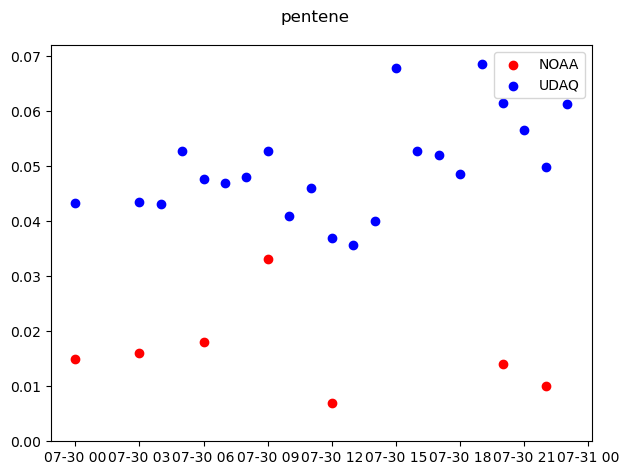

Which is better for pentene on 2024-07-30? Press U for 'UDAQ' and 'N' for NOAA u


In [45]:
import pandas as pd 
import xarray as xr 
import numpy as np 
import matplotlib.pyplot as plt



def plot_both(noaa, udaq, voc_dict, VOC, date):
    start = pd.to_datetime(date)
    stop = start + pd.Timedelta(days=1)
    
    noaa_sel = noaa[noaa['time_local'].between(start, stop, inclusive='left')]
    udaq_sel = udaq[ udaq.index.to_series().between(start, stop, inclusive='left')]
    
    noaa_name=voc_dict[VOC]['NOAA'] 
    udaq_name=voc_dict[VOC]['UDAQ'] 
    
    noaa_var=noaa_sel[noaa_name]   # time_UTC
    udaq_var=udaq_sel[udaq_name] # time_local as index 
    
    mx=np.nanmax([np.nanmax(noaa_var), np.nanmax(udaq_var)])
    
    fig, ax1=plt.subplots(nrows=1, ncols=1)
    ax1.scatter(noaa_sel['time_local'], noaa_var, color = 'r', label='NOAA') 
    ax1.scatter(udaq_sel.index, udaq_var, color = 'b', label='UDAQ') 
    fig.suptitle(VOC)
    ax1.set_ylim([0,1.05*mx]) 
    ax1.legend() 
    plt.tight_layout()
    plt.show()
    
    return 

def which_is_better(file, date, VOC, preferred): 
   
    line=f"{date}, {VOC}, {preferred}\n"

    with open(file, 'a') as f : 
        f.write(line)
    return 
    
udaq_f='/uufs/chpc.utah.edu/common/home/u1545774/hgrup_vsun/USOS_shared/Hawthorne_data/data/hawthorne_udaq_all_vocs_15min_timezone_carbon_number_updated.csv'
noaa_f='/uufs/chpc.utah.edu/common/home/u1545774/hgrup_vsun/USOS_shared/CampaignData_and_Merges/R0/CSL_MobileLab_Parked/merged/rev_15min/all_CSL_MobileLab_Parked_rev15min_iWASupdated.nc'

file='/uufs/chpc.utah.edu/common/home/u1545774/hgrup_vsun/USOS_shared/log.txt'

udaq= pd.read_csv(udaq_f, index_col=0, parse_dates=True) 

ds=xr.open_dataset(noaa_f)
noaa= ds.to_dataframe()


voc_dict={'pentene': {'NOAA': 'x1_Pentene_WAS', 'UDAQ':'Pent1ene'}}


# for voc_in vocs: 
#     for date_i in dates: 
date_i = '2024-07-30'
voc_i='pentene'


plot_both(noaa, udaq, voc_dict, voc_i, date) 

preferred=input(f"Which is better for {voc_i} on {date_i}? Press U for 'UDAQ' and 'N' for NOAA")
if preferred.lower() =='u': 
    pref=f"UDAQ.{voc_dict[voc_i]['UDAQ']}"
elif preferred.lower()=='n': 
    pref=f"NOAA.{voc_dict[voc_i]['NOAA']}"
else: 
    print('try again')
    
which_is_better(file, date_i, voc_i, pref)
    



In [ ]:
#include ratio of medians